In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import astropy.units as u
from astropy import wcs
from astropy.io import fits
from astropy.visualization import simple_norm, MinMaxInterval, AsinhStretch, AsymmetricPercentileInterval, make_rgb
from astropy.coordinates import SkyCoord
from acstools import acszpt
import scipy.ndimage as nd
import matplotlib.patches as patches
from matplotlib.path import Path
#import sys
#sys.path.append('../scripts')
#from Conversion_functions import WFC_unit_conv


In [2]:
def WFC_unit_conv(image, filt, date ='2022-09-11', output='VEGAmag'):
    """
    Converts image values from cps to magnitudes using the HST conversion parameters.
    Since it uses active Query, this function needs internet connection to work. 

    Args
    - image is the image needed to be converted.
    - filt is filter name as string, eg 'F555W'. 
    - date is string in format 'yyyy-mm-dd'
    - output is the desired output units, either 'flux_density', or 'STmag', 'ABmag', or 'VEGAmag' for magnitudes.
        Flux density will be given in erg/s/cm^2/Angstrom.

    Returns
    - image with values in desired units.
    """
    q = acszpt.Query(date=date, detector='WFC', filt=filt)
    filter_zpt = q.fetch()
    if output == 'flux_density':
        F_lambda = image * u.electron/u.s * filter_zpt['PHOTFLAM']
        return F_lambda.value
    else:
        m = -2.5 * np.log10(image) + filter_zpt[output][0].value
        return m


In [ ]:
#  loading the two image files from ACS F555W and ACS F814W
filename555= '../Data_HST/hst_16890_03_acs_wfc_f555w_jesd03'
hdu_f555w = fits.open(filename555+'_drc.fits')
im555 = fits.getdata(filename555+'_drc.fits')

filename814= '../Data_HST/hst_16890_03_acs_wfc_f814w_jesd03'
hdu_f814w = fits.open(filename814+'_drc.fits')
im814 = fits.getdata(filename814+'_drc.fits')

# converting from cps to magnitudes
magim814 = WFC_unit_conv(im814, filt='F814W', output='VEGAmag')
magim555 = WFC_unit_conv(im555, filt='F555W', output='VEGAmag')

wcs_HST = wcs.WCS(hdu_f555w[1].header)
#prints error because images contain nans, but it works

/var/folders/6c/yf7kbvpn3wg721sk085c5d2r0000gn/T/ipykernel_5315/2876516124.py:22: RuntimeWarning: invalid value encountered in log10
  m = -2.5 * np.log10(image) + filter_zpt[output][0].value
/var/folders/6c/yf7kbvpn3wg721sk085c5d2r0000gn/T/ipykernel_5315/2876516124.py:22: RuntimeWarning: invalid value encountered in log10
  m = -2.5 * np.log10(image) + filter_zpt[output][0].value


In [4]:
pixsize_arc = hdu_f555w[0].header['D001SCAL'] # pixel size in arcsec
pix_to_pc = pixsize_arc*u.arcsec.to(u.rad)*35.2e6*u.pc
px_size = pix_to_pc.value

print(f'Pixel size in arcsec: {pixsize_arc:.3f}')
print(f'Pixel size in pc: {pix_to_pc.value:.3f}')

Pixel size in arcsec: 0.050
Pixel size in pc: 8.533


In [5]:
def smooth_image(image, type = 'gaussian', param = 2.5):
    # make copy and replace NaNs with 0s to avoid edge effects
    im_nonan = image.copy()
    im_nonan[np.isnan(im_nonan)]=0.0

    if type == 'gaussian':
        return nd.gaussian_filter(im_nonan, sigma=param, mode='wrap')
    elif type == 'uniform':
        return nd.uniform_filter(im_nonan, size=param, mode='wrap')


In [6]:
CFHT_G = fits.open('../Data_CFHT_cropped/CFHTLS_W_g_141202+514231_T0007_MEDIAN_cutout.fits')
CFHT_I = fits.open('../Data_CFHT_cropped/CFHTLS_W_g_141202+514231_T0007_MEDIAN_cutout.fits')

wcs_CFHT = wcs.WCS(CFHT_G[0].header)
G_im = CFHT_G[0].data
CFHT_G.info()


the RADECSYS keyword is deprecated, use RADESYSa. [astropy.wcs.wcs]
the RADECSYS keyword is deprecated, use RADESYSa.


Filename: ../Data_CFHT_cropped/CFHTLS_W_g_141202+514231_T0007_MEDIAN_cutout.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU      90   (269, 269)   float32   


In [ ]:
normCFHT = simple_norm(G_im, 'asinh', min_percent=40, max_percent=98, clip=True)
#smooth_G_im = smooth_image(G_im, 'uniform',param=3)
smooth_G_im = smooth_image(G_im, param=1.5)

In [8]:
#coordinates of host galaxy center from Fielder+23
cent =SkyCoord("14h09m13 +51d13m28s", unit=(u.hourangle), frame='icrs')
cent_WCS = cent.to_pixel(wcs_HST, 1)

One-and-a-half column figure

/opt/anaconda3/lib/python3.12/site-packages/astropy/visualization/basic_rgb.py:153: RuntimeWarning: invalid value encountered in cast
  return image_rgb.astype(output_dtype)


Text(24, 195, 'g')

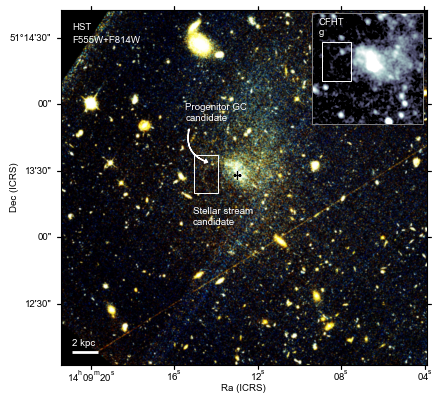

In [ ]:
plt.rcParams.update({
    'font.family': 'Arial',
    'font.size': 7,
    'mathtext.default': 'regular',
})

markcol = 'w'
fsize = 7
s = 1

#rgb color scaling
r_up = 93
r_low = 80
b_up = 93
b_low = 80
g_up = np.mean([r_up, b_up])
g_low = np.mean([r_low, b_low]) + 5

figsize_mm = 120 #183 #89
fig = plt.figure(figsize=(figsize_mm / 25.4, figsize_mm / 25.4)) #in inches
ax = plt.subplot(projection=wcs_HST)

lupton = make_rgb(im814, np.mean([im814,im555], axis=0),im555, interval = np.array([AsymmetricPercentileInterval(r_low, r_up),AsymmetricPercentileInterval(g_low, g_up),AsymmetricPercentileInterval(b_low, b_up)])
                  #, stretch=LinearStretch()
                  , stretch = AsinhStretch(.3)
                  )
lupton_s = make_rgb(nd.gaussian_filter(im814,s), np.mean([nd.gaussian_filter(im814,s),nd.gaussian_filter(im555,s)], axis=0),nd.gaussian_filter(im555,s), 
                    interval = np.array([AsymmetricPercentileInterval(80, 95),AsymmetricPercentileInterval(80, 95),AsymmetricPercentileInterval(80, 95)])
                  #, stretch=LinearStretch()
                  , stretch = AsinhStretch(.3)
                  )

ax.imshow(nd.gaussian_filter(lupton_s, (3,3,0))) #last index affects the colour

ax.set_xlim(1300, 4500)
ax.set_ylim(1500, 4700)
ax.set_ylabel('Dec (ICRS)', fontfamily='sans-serif', fontsize=fsize, labelpad=-0.5, color='k')
ax.set_xlabel('Ra (ICRS)', fontfamily='sans-serif', fontsize=fsize, labelpad=0.5, color='k')
ax.tick_params(axis='both', colors='k', labelsize=fsize, length=3, direction='out')

ax.text(1310, 4520, 'HST', color='w', fontfamily='sans-serif', fontsize=fsize)
ax.text(1310, 4400, 'F555W+F814W', color='w', fontfamily='sans-serif', fontsize=fsize)

ax.text(2325, 3800, 'Progenitor GC', color=markcol, fontfamily='sans-serif',fontsize=fsize)
ax.text(2325, 3700, 'candidate', color=markcol, fontfamily='sans-serif',fontsize=fsize)

ax.text(2390, 2860, 'Stellar stream', color=markcol, fontfamily='sans-serif',fontsize=fsize)
ax.text(2390, 2760, 'candidate', color=markcol, fontfamily='sans-serif',fontsize=fsize)

# cross, arrow and box to mark features
ax.plot(cent_WCS[0], cent_WCS[1], 'k', marker='+', markersize=6) #host centre
arrow1 = patches.FancyArrowPatch((2365, 3650), (2550, 3320),
                             connectionstyle="arc3,rad=.5", color=markcol, arrowstyle="Simple, tail_width=0.02, head_width=3, head_length=2")
box1 = patches.Rectangle((2400, 3050), 220, 340, linewidth=0.7, edgecolor=markcol, facecolor='none')
ax.add_patch(arrow1)
ax.add_patch(box1)

ax.set_xlim(1200, 4500)
ax.set_ylim(1500, 4700)

# 2 kpc scale bar in the lower-left corner (1 px = 8.53 pc)
kpc_px = 2000 / px_size
x0, y0 = 1300, 1620
ax.hlines(y0, x0, x0 + kpc_px, color='w', linewidth=2)
ax.text(x0, y0 + 55, '2 kpc', color='w', fontfamily='sans-serif', fontsize=fsize)

# CFHT insert
axins = ax.inset_axes(
    [3470, 3670, 1000, 1000], transform=ax.transData,
    #xlim=(0, 250), ylim=(555, 395), 
    xticklabels=[], yticklabels=[]
    )
axins.imshow(smooth_G_im, norm=normCFHT, cmap='bone', origin='lower', aspect=1)
axins.set_xlim(10, 240)
axins.set_ylim(10, 240)
axins.spines['bottom'].set_color('grey')
axins.spines['bottom'].set_linewidth(0.7)
axins.spines['top'].set_color('grey')
axins.spines['top'].set_linewidth(0.7)
axins.spines['left'].set_color('grey')
axins.spines['left'].set_linewidth(0.7)
axins.spines['right'].set_color('grey')
axins.spines['right'].set_linewidth(0.7)
axins.tick_params(axis='x', bottom=False)
axins.tick_params(axis='y', left=False)

box2 = patches.Rectangle((30, 100), 60, 80, linewidth=0.7, edgecolor='w', facecolor='none')
axins.add_patch(box2)

axins.text(22, 215, 'CFHT', color='w', fontfamily='sans-serif', fontsize=fsize)
axins.text(24, 195, 'g', color='w', fontfamily='sans-serif', fontsize=fsize)
#fig.savefig('../Figures/Data_formatted_120mm.eps', format='eps', bbox_inches='tight', transparent=False)

Double column figure

/opt/anaconda3/lib/python3.12/site-packages/astropy/visualization/basic_rgb.py:153: RuntimeWarning: invalid value encountered in cast
  return image_rgb.astype(output_dtype)


Text(24, 195, 'g')

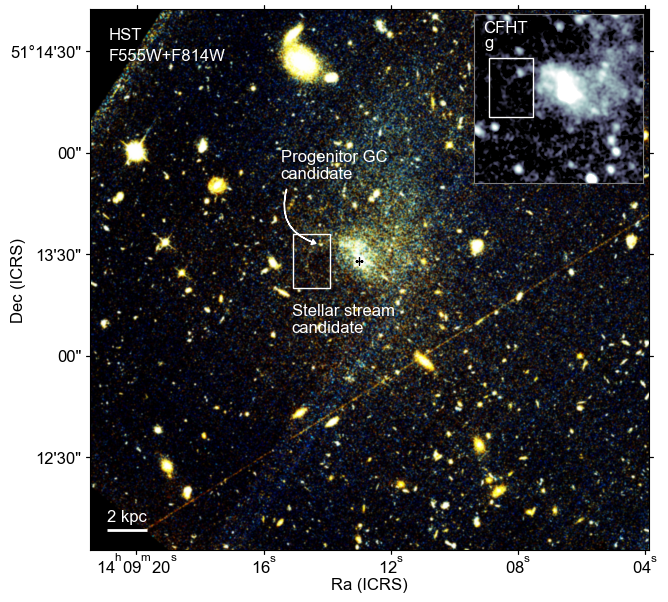

In [ ]:
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial'],#'DejaVu Sans'],
    'mathtext.default': 'regular',
})

markcol = 'w'
fsize = 12
s = 1

r_up = 93
r_low = 80
b_up = 93
b_low = 80
g_up = np.mean([r_up, b_up])
g_low = np.mean([r_low, b_low]) + 5

figsize_mm = 183 #120 #89
fig = plt.figure(figsize=(figsize_mm / 25.4, figsize_mm / 25.4)) #120 mm in inches
ax = plt.subplot(projection=wcs_HST)
# reduce margins so image fills figure
#fig.subplots_adjust(left=0.06, right=0.99, bottom=0.06, top=0.99)
#ax.set_position([0.06, 0.06, 0.92, 0.92])

lupton = make_rgb(im814, np.mean([im814,im555], axis=0),im555, interval = np.array([AsymmetricPercentileInterval(r_low, r_up),AsymmetricPercentileInterval(g_low, g_up),AsymmetricPercentileInterval(b_low, b_up)])
                  #, stretch=LinearStretch()
                  , stretch = AsinhStretch(.3)
                  )
lupton_s = make_rgb(nd.gaussian_filter(im814,s), np.mean([nd.gaussian_filter(im814,s),nd.gaussian_filter(im555,s)], axis=0),nd.gaussian_filter(im555,s), 
                    interval = np.array([AsymmetricPercentileInterval(80, 95),AsymmetricPercentileInterval(80, 95),AsymmetricPercentileInterval(80, 95)])
                  #, stretch=LinearStretch()
                  , stretch = AsinhStretch(.3)
                  )
#ax.imshow(nd.gaussian_filter(lupton, (s,s,0))) #last index affects the colour
ax.imshow(nd.gaussian_filter(lupton_s, (3,3,0)))

ax.set_xlim(1300, 4500)
ax.set_ylim(1500, 4700)
ax.set_ylabel('Dec (ICRS)', fontfamily='sans-serif', fontsize=fsize, labelpad=-0.5, color='k')
ax.set_xlabel('Ra (ICRS)', fontfamily='sans-serif', fontsize=fsize, labelpad=0.5, color='k')
# smaller tick labels and ticks
ax.tick_params(axis='both', colors='k', labelsize=fsize, length=3, direction='out')

ax.text(1310, 4520, 'HST', color='w', fontfamily='sans-serif', fontsize=fsize)
ax.text(1310, 4400, 'F555W+F814W', color='w', fontfamily='sans-serif', fontsize=fsize)

ax.text(2325, 3800, 'Progenitor GC', color=markcol, fontfamily='sans-serif',fontsize=fsize)
ax.text(2325, 3700, 'candidate', color=markcol, fontfamily='sans-serif',fontsize=fsize)

ax.text(2390, 2890, 'Stellar stream', color=markcol, fontfamily='sans-serif',fontsize=fsize)
ax.text(2390, 2790, 'candidate', color=markcol, fontfamily='sans-serif',fontsize=fsize)
ax.plot(cent_WCS[0], cent_WCS[1], 'k', marker='+', markersize=6)

arrow1 = patches.FancyArrowPatch((2365, 3650), (2550, 3310),
                             connectionstyle="arc3,rad=.5", color=markcol, arrowstyle="Simple, tail_width=0.2, head_width=4, head_length=3")
box1 = patches.Rectangle((2400, 3050), 220, 320, linewidth=1, edgecolor=markcol, facecolor='none')
ax.add_patch(arrow1)
ax.add_patch(box1)

ax.set_xlim(1200, 4500)
ax.set_ylim(1500, 4700)

# 2 kpc scale bar in the lower-left corner (1 px = 8.53 pc)
kpc_px = 2000 / 8.53
x0, y0 = 1300, 1620
ax.hlines(y0, x0, x0 + kpc_px, color='w', linewidth=2)
ax.text(x0, y0 + 55, '2 kpc', color='w', fontfamily='sans-serif', fontsize=fsize)

# CFHT insert
axins = ax.inset_axes(
    [3470, 3670, 1000, 1000], transform=ax.transData,
    #xlim=(0, 250), ylim=(555, 395), 
    xticklabels=[], yticklabels=[]
    )
axins.imshow(smooth_G_im, norm=normCFHT, cmap='bone', origin='lower', aspect=1)
axins.set_xlim(10, 240)
axins.set_ylim(10, 240)
axins.spines['bottom'].set_color('grey')
axins.spines['top'].set_color('grey')
axins.spines['left'].set_color('grey')
axins.spines['right'].set_color('grey')
axins.tick_params(axis='x', bottom=False)
axins.tick_params(axis='y', left=False)

box2 = patches.Rectangle((30, 100), 60, 80, linewidth=1, edgecolor='w', facecolor='none')
axins.add_patch(box2)

axins.text(22, 215, 'CFHT', color='w', fontfamily='sans-serif', fontsize=fsize)
axins.text(24, 195, 'g', color='w', fontfamily='sans-serif', fontsize=fsize)
#fig.savefig('../Figures/Data_formatted_183mm.eps', format='eps', bbox_inches='tight', transparent=False)